In [3]:
import os
from gtts import gTTS
from pydub import AudioSegment

sentences = [
    "Hello, this is a test sentence for our dataset.",
    "We are generating synthetic speech for the robustness experiment.",
    "This recording will help evaluate the robustness of our audio features.",
    "Please speak clearly and naturally while reading these lines.",
    "The quick brown fox jumps over the lazy dog, a classic pangram for testing.",
    "Our experiment requires clean and noisy samples to compare results.",
    "Make sure to enunciate each word so it is easy to understand.",
    "Background noise can affect speech recognition performance.",
    "We will also test how reverberation changes the spectral features.",
    "Thank you for contributing your voice to this research project." 
]

output_dir = "synthetic_speech"
os.makedirs(output_dir, exist_ok=True)

for idx, text in enumerate(sentences):
    # Generate MP3
    tts = gTTS(text=text, lang='en', slow=False)
    mp3_path = os.path.join(output_dir, f"sample_{idx}.mp3")
    tts.save(mp3_path)

    # Convert MP3 to WAV(16kHz, mono)
    sound = AudioSegment.from_file(mp3_path)
    sound = sound.set_frame_rate(16000).set_channels(1)
    wav_path = os.path.join(output_dir, f"sample_{idx}.wav")
    sound.export(wav_path, format="wav")

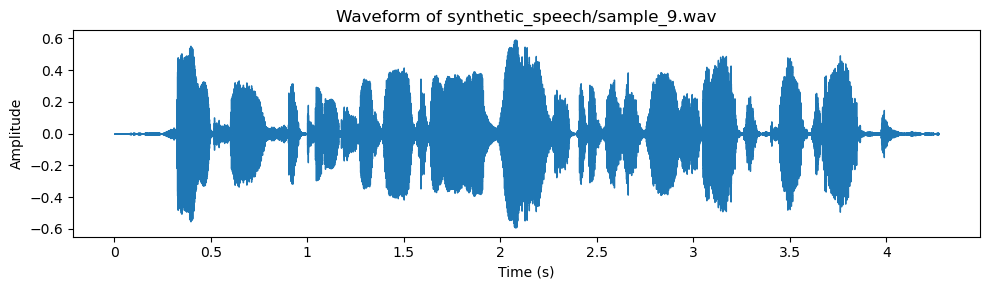

In [28]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

file_path = "synthetic_speech/sample_9.wav"  

# Load as mono, keep original sampling rate
y, sr = librosa.load(file_path, sr=None, mono=True)

# Plot 
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform of {file_path}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Play the full signal
Audio(y, rate=sr)